In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../../data/product_type_2.csv", header=[0,1])
df

process                                                     \
           id product_type shot velocity_1 velocity_2 velocity_3   
0     4207011            2   11      0.156      0.166      0.192   
1     4208012            2   12      0.157      0.166      0.204   
2     4209013            2   13      0.156      0.170      0.204   
3     4210014            2   14      0.154      0.170      0.202   
4     4211015            2   15      0.146      0.160      0.198   
...       ...          ...  ...        ...        ...        ...   
1959  7525657            2  657      0.144      0.173      0.200   
1960  7527658            2  658      0.144      0.173      0.200   
1961  7529659            2  659      0.150      0.166      0.210   
1962  7531660            2  660      0.144      0.174      0.206   
1963  7533661            2  661      0.147      0.174      0.204   

                                                                        ...  \
     high_velocity cylinder_pressure rapid_rise_time biscuit_thickness  ...   
0            2.723               265           0.012                20  ...   
1            2.730               264           0.014                19  ...   
2            2.715               265           0.012                18  ...   
3            2.717               264           0.011                20  ...   
4            2.684               264           0.012                20  ...   
...            ...               ...             ...               ...  ...   
1959         2.536               264           0.012                17  ...   
1960         2.536               264           0.012                17  ...   
1961         2.492               265           0.011                17  ...   
1962         2.514               264           0.011                16  ...   
1963         2.532               265           0.012                18  ...   

     defects                                                          \
     stain_2 dent_2 deformation_2 contamination_2 impurity_2 crack_2   
0          0      0             0               0          0       0   
1          0      0             0               0          0       0   
2          0      0             0               0          0       0   
3          0      0             0               0          0       0   
4          0      0             0               0          0       0   
...      ...    ...           ...             ...        ...     ...   
1959       0      0             0               0          0       0   
1960       0      0             0               0          0       0   
1961       0      0             0               0          0       0   
1962       0      0             0               0          0       0   
1963       0      0             0               0          0       0   

                                          defect_flag  
     scratch_2 buring_mark_2 inclusions_2   is_defect  
0            0             0            0           0  
1            0             0            0           0  
2            0             0            0           0  
3            0             0            0           0  
4            0             0            0           0  
...        ...           ...          ...         ...  
1959         0             0            0           0  
1960         0             0            0           0  
1961         0             0            0           0  
1962         0             0            0           1  
1963         0             0            0           1  

[1964 rows x 58 columns]

In [33]:
### 1. 불필요한 id, product_type, shot 컬럼 제거
df = df.drop(columns=[('process', 'id'), ('process', 'shot'), ('process', 'product_type')])

In [34]:
### 2. 값이 전부 0인 defects 컬럼 drop
# Defects 하위 컬럼들
defect_cols = df['defects'].columns

# 값이 전부 0인 Defects 컬럼 찾기
zero_defects = [
    col for col in defect_cols
    if df[('defects', col)].sum() == 0
]

# 결과 출력
print("삭제될 defects 컬럼:")
print(zero_defects)

print("\n삭제될 컬럼 수:", len(zero_defects))
print("삭제 전 defects 컬럼 수:", len(defect_cols))

# 실제 삭제
df = df.drop(columns=[('defects', col) for col in zero_defects])

print("삭제 후 defects 컬럼 수:", len(df['defects'].columns))

삭제될 defects 컬럼:
['exfoliation_1', 'deformation_1', 'inclusions_1', 'bubble_2', 'exfoliation_2', 'stain_2', 'deformation_2', 'scratch_2', 'buring_mark_2']

삭제될 컬럼 수: 9
삭제 전 defects 컬럼 수: 26
삭제 후 defects 컬럼 수: 17


In [35]:
df['defects'].sum().sort_values(ascending=False)

short_shot_1       176
blow_hole_1        112
stain_1             93
blow_hole_2         79
short_shot_2        48
contamination_2      8
buring_mark_1        5
impurity_2           5
dent_1               4
contamination_1      4
dent_2               4
impurity_1           2
scratch_1            2
crack_2              2
bubble_1             1
crack_1              1
inclusions_2         1
dtype: int64

In [36]:
# 불량 범주 정의 (suffix _1, _2 자동 처리)
defect_groups = {
    "표면": [
        "stain_1",
        "dent_1",
        "dent_2",
        "scratch_1",
        "buring_mark_1"
    ],

    "구조": [
        "short_shot_1",
        "short_shot_2",
        "blow_hole_1",
        "blow_hole_2",
        "bubble_1",
        "crack_1",
        "crack_2"
    ],

    "이물질": [
        "contamination_1",
        "contamination_2",
        "impurity_1",
        "impurity_2",
        "inclusions_2"
    ]
}

In [37]:
import numpy as np
import pandas as pd

defects = df['defects'].copy()  # columns: Short_Shot_1, Blow_Hole_2, ...

# 각 범주별로 해당하는 defect 컬럼들을 찾아서 "하나라도 1이면 1"로 만들기
y_group = pd.DataFrame(index=df.index)

for group_name, base_names in defect_groups.items():
    # base_names 중 하나로 시작하는 컬럼들 찾기 (예: "Short_Shot" -> "Short_Shot_1", "Short_Shot_2")
    cols = [c for c in defects.columns if any(str(c).startswith(b) for b in base_names)]
    
    if len(cols) == 0:
        # 해당 범주에 매칭되는 컬럼이 없으면 0으로
        y_group[group_name] = 0
    else:
        y_group[group_name] = (defects[cols].fillna(0).astype(int).sum(axis=1) > 0).astype(int)

print(y_group.sum().sort_values(ascending=False))   # 범주별 발생 건수 확인
print(y_group.mean().mul(100))                      # 범주별 발생률(%) 확인

구조     395
표면     107
이물질     19
dtype: int64
표면      5.448065
구조     20.112016
이물질     0.967413
dtype: float64


In [38]:
# X = 공정 변수
X = df['process']

# y = 불량 범주
y = y_group

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [29]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

xgb = XGBClassifier(
    tree_method="hist",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model = MultiOutputClassifier(xgb)

model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,"XGBClassifier...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None


In [30]:
proba = model.predict_proba(X_test)

import numpy as np
proba_matrix = np.column_stack([p[:, 1] for p in proba])

threshold = 0.3
y_pred = (proba_matrix >= threshold).astype(int)

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.09      0.08      0.08        13
           1       0.32      0.32      0.32        81
           2       0.00      0.00      0.00         3

   micro avg       0.28      0.28      0.28        97
   macro avg       0.14      0.13      0.13        97
weighted avg       0.28      0.28      0.28        97
 samples avg       0.07      0.06      0.07        97



c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

In [18]:
print(X_train.shape)

(1571, 14)


In [19]:
print(y_group.mean())

표면     0.054481
구조     0.201120
이물질    0.009674
dtype: float64


In [20]:
import pandas as pd

importance = model.estimators_[1].feature_importances_

feat_imp = pd.Series(importance, index=X_train.columns)

feat_imp.sort_values(ascending=False).head(10)

spray_2_time          0.302908
high_velocity         0.110017
spray_time            0.065015
cycle_time            0.057402
clamping_force        0.055530
velocity_1            0.050960
velocity_2            0.050576
casting_pressure      0.048374
biscuit_thickness     0.046649
pressure_rise_time    0.045457
dtype: float32

In [21]:
X_train.columns

Index(['velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'],
      dtype='str')

In [9]:
y_group.sum(axis=1).value_counts()

0    1467
1     473
2      24
Name: count, dtype: int64

In [10]:
X = df[['Process','Sensor']].copy()

In [11]:
X.columns = ['_'.join(col) for col in X.columns]

In [12]:
len(X.columns)

29

In [13]:
y = y_group

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

model = MultiOutputClassifier(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
)

model.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,RandomForestC...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the f

In [16]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.45      0.12      0.19        81
           2       0.00      0.00      0.00         3

   micro avg       0.40      0.10      0.16        97
   macro avg       0.15      0.04      0.06        97
weighted avg       0.38      0.10      0.16        97
 samples avg       0.03      0.03      0.03        97



c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

In [18]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report).T

label_names = ["구조", "표면", "이물질"]
report_df = report_df.rename(columns={
    "precision": "정밀도",
    "recall": "재현율",
    "f1-score": "F1 점수",
    "support": "샘플 수"
})

print(report_df)

                   정밀도       재현율     F1 점수  샘플 수
0             0.000000  0.000000  0.000000  13.0
1             0.454545  0.123457  0.194175  81.0
2             0.000000  0.000000  0.000000   3.0
micro avg     0.400000  0.103093  0.163934  97.0
macro avg     0.151515  0.041152  0.064725  97.0
weighted avg  0.379569  0.103093  0.162146  97.0
samples avg   0.025445  0.025445  0.025445  97.0


c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\Desktop\project_LSB\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

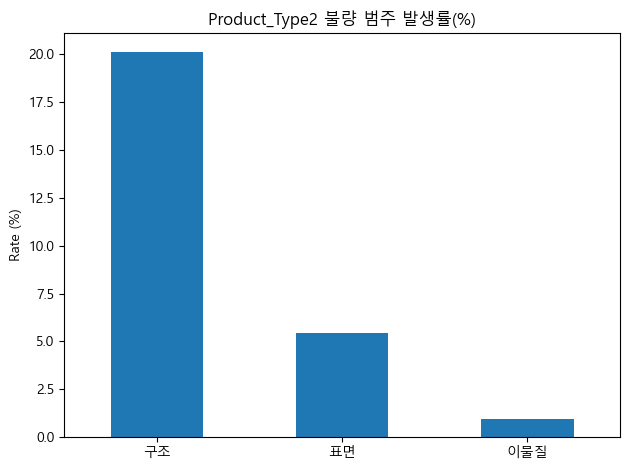

In [25]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

(y_group.mean()*100).sort_values(ascending=False).plot(kind="bar")
plt.title("Product_Type2 불량 범주 발생률(%)")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

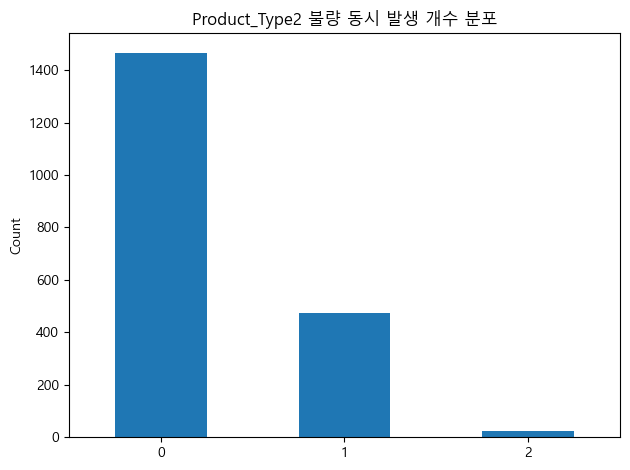

In [26]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

y_group.sum(axis=1).value_counts().sort_index().plot(kind="bar")
plt.title("Product_Type2 불량 동시 발생 개수 분포")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

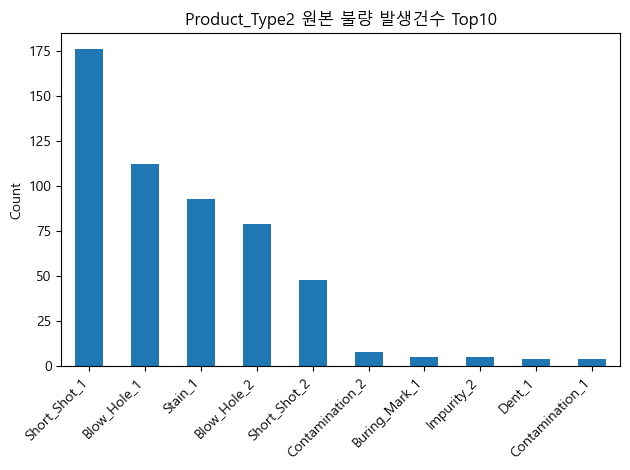

In [27]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df['Defects'].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Product_Type2 원본 불량 발생건수 Top10")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
### 3. 남은 defects 중 이상치 확인